In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, RepeatedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBRegressor
from sklearn.feature_selection import mutual_info_regression
import matplotlib.pyplot as plt

# 1. Paths & Load Data
target_name = 'SalePrice'
train_url = '../input/train.csv'
test_url = '../input/test.csv'

X_full = pd.read_csv(train_url, index_col='Id')
X_test_full = pd.read_csv(test_url, index_col='Id')

X_full.head(10)

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pan

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900


In [15]:
# Remove rows with missing target
X_full.dropna(axis=0, subset=[target_name], inplace=True)
y = X_full[target_name]
X_full.drop([target_name], axis=1, inplace=True)

# Break off validation set from training data
X_train_full, X_valid_full, y_train, y_valid = train_test_split(X_full, y, train_size=0.8, test_size=0.2,random_state=0)

# 2. Select Columns
numerical_cols = [cname for cname in X_train_full.columns if X_train_full[cname].dtype in ['int64', 'float64']]

categorical_cols = [cname for cname in X_train_full.columns if X_train_full[cname].nunique() < 10 and X_train_full[cname].dtype == "object"]

# if 'Id' in numerical_cols: 
#     numerical_cols.remove('Id')

# Keep selected columns only
my_cols = categorical_cols + numerical_cols
X_train = X_train_full[my_cols].copy()
X_valid = X_valid_full[my_cols].copy()
X_test = X_test_full[my_cols].copy()

X_train_full.head(10)

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pan

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
Id,,,,,,,,,,,,,,,,,,,,,
619,20,RL,90.0,11694,Pave,NaN,Reg,Lvl,AllPub,Inside,...,260,0,NaN,NaN,NaN,0,7,2007,New,Partial
871,20,RL,60.0,6600,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,8,2009,WD,Normal
93,30,RL,80.0,13360,Pave,Grvl,IR1,HLS,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,8,2009,WD,Normal
818,20,RL,NaN,13265,Pave,NaN,IR1,Lvl,AllPub,CulDSac,...,0,0,NaN,NaN,NaN,0,7,2008,WD,Normal
303,20,RL,118.0,13704,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,0,NaN,NaN,NaN,0,1,2006,WD,Normal
1455,20,FV,62.0,7500,Pave,Pave,Reg,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,10,2009,WD,Normal
41,20,RL,84.0,8658,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,GdWo,NaN,0,12,2006,WD,Abnorml
960,160,FV,24.0,2572,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal
76,180,RM,21.0,1596,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,GdWo,NaN,0,11,2009,WD,Normal


In [16]:
# 3. Pipeline Setup
numerical_transformer = SimpleImputer(strategy='mean', add_indicator=True)

categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent', add_indicator=True)),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]
)

# Bundle preprocessing for numerical and categorical data
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

print("Preprocessing completed successfully")

Preprocessing completed successfully


--- Calculating & Plotting Mutual Information ---


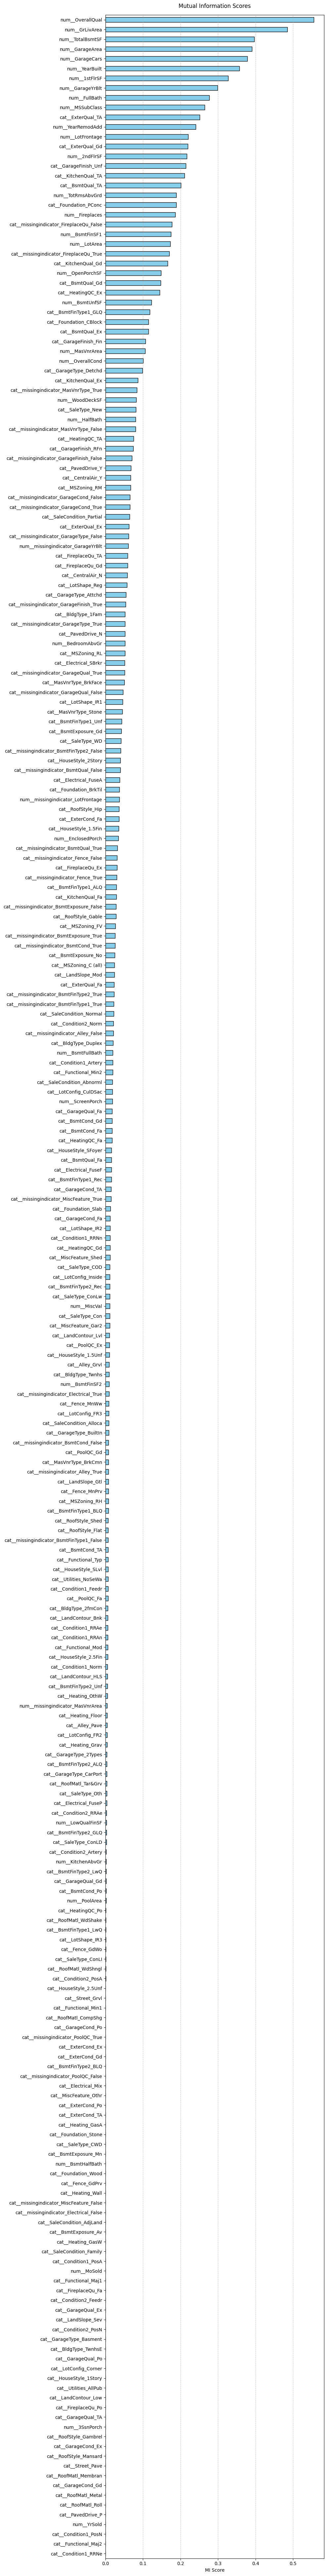

Top Feature Scores:
num__OverallQual             0.554696
num__GrLivArea               0.484428
num__TotalBsmtSF             0.396264
num__GarageArea              0.390195
num__GarageCars              0.377659
                               ...   
cat__BsmtExposure_Av         0.000000
cat__Heating_GasW            0.000000
cat__SaleCondition_Family    0.000000
cat__Condition1_PosA         0.000000
cat__Condition1_RRNe         0.000000
Length: 261, dtype: float64


In [17]:
# 5. Calculating and graphing Mutual Information (MI)
print('--- Calculating & Plotting Mutual Information ---')

X_train_transformed = preprocessor.fit_transform(X_train)
feature_names = preprocessor.get_feature_names_out()

mi_scores = mutual_info_regression(X_train_transformed, y_train, random_state=0)
mi_series = pd.Series(mi_scores, index=feature_names).sort_values(ascending=True)

plt.figure(figsize=(10, round(mi_series.count() * 0.3)), dpi=100)
mi_series.plot(kind='barh', color='skyblue', edgecolor='black')
plt.title('Mutual Information Scores', fontsize=12, pad=15)
plt.xlabel('MI Score', fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Top Feature Scores:")
print(mi_series.sort_values(ascending=False))

In [ ]:
# use XGBRegressor
base_model = XGBRegressor(
    random_state=0,
    eval_metric='rmse'
)

my_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', base_model)
    ]
)

# 4. Hyperparameter Tuning with GridSearchCV
param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [3, 4, 6],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0]
}

# use RepeatedKFold
cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=0)

# use neg_root_mean_squared_error
grid_search = GridSearchCV(
    estimator=my_pipeline, 
    param_grid=param_grid, 
    cv=cv, 
    scoring='neg_root_mean_squared_error', 
    n_jobs=-1, 
    verbose=1
)

print('Searching for best parameters with XGBoost Regressor...')
grid_search.fit(X_train_full, y_train)

print('--- Result ---')
print('Best Parameters:', grid_search.best_params_)

print('Best Validation RMSE:', -grid_search.best_score_)

In [ ]:
# 5. Final Fit on Full Dataset with Best Parameters & Predict
best_pipeline = grid_search.best_estimator_
best_pipeline.fit(X_full_selected, y)

preds_test = best_pipeline.predict(X_test)

# 6. Submission File
id_cols = [col for col in X_test_full.columns if col.lower() == 'id']

if id_cols:
    test_id = X_test_full[id_cols[0]]
else:
    test_id = X_test_full.index

output = pd.DataFrame({
    'Id': test_id, 
    target_name: preds_test
})

output.to_csv('submission.csv', index=False)
print("Your XGBoost Regressor submission was successfully saved!")